# Eksperimen 12 — Error Analysis: Analisis Kasus Salah Klasifikasi

## Deskripsi

Notebook ini melakukan **Analisis Kesalahan (Error Analysis)** terhadap model **Full AttentiveSkel-3D** untuk memahami *mengapa* model melakukan kesalahan klasifikasi pada kasus-kasus tertentu.

Dua jenis kesalahan yang dianalisis:

| Jenis Error | Definisi | Implikasi |
|---|---|---|
| **False Positive (FP)** | Label asli = 0 (Benar), Prediksi = 1 (Salah) | Model menganggap gerakan yang sebenarnya benar sebagai salah |
| **False Negative (FN)** | Label asli = 1 (Salah), Prediksi = 0 (Benar) | Model menganggap gerakan yang sebenarnya salah sebagai benar (**lebih berbahaya secara praktis**) |

---

## Alur Analisis

1. Load `dataset_manifest.csv` dan jalankan inferensi penuh
2. Identifikasi kasus **False Positive** dan **False Negative** pertama yang ditemukan
3. Ekstrak bobot atensi BSP dari model per sendi (33 landmark BlazePose)
4. Visualisasi skeleton berbasis atensi dari frame tengah tensor masing-masing kasus
5. Interpretasi: sendi mana yang menjadi fokus model saat ia membuat kesalahan?

---

## Hipotesis

- **False Positive**: Model mungkin memberikan atensi berlebih pada sendi yang tidak relevan sehingga keliru mendeteksi "bentuk cacat" pada gerakan yang sebenarnya benar.
- **False Negative**: Model mungkin gagal merespons sinyal biomekanis yang halus (misalnya *rounded back deadlift* yang subtil) karena distribusi atensi tersebar merata dan tidak fokus.

# 1. Setup & Load Model Terbaik

Setup dilakukan dengan:
- Menambahkan direktori root proyek ke `PYTHONPATH`
- Mengimpor seluruh library yang diperlukan
- Memuat checkpoint `AttentiveSkel3D_Final.pth` dengan `strict=False` dan `weights_only=True`
- Mengekstrak bobot atensi BSP ke array `(33,)` yang akan dipakai di seluruh notebook

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import mediapipe as mp

warnings.filterwarnings("ignore")

# =============================================================================
# Setup sys.path
# =============================================================================

ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.models.model_3dcnn import AttentiveSkel3D

# =============================================================================
# Muat Model Terbaik (AttentiveSkel3D_Final.pth)
# =============================================================================

MODEL_PATH = ROOT_DIR / "models" / "saved_models" / "AttentiveSkel3D_Final.pth"
MANIFEST_PATH = ROOT_DIR / "data" / "processed" / "dataset_manifest.csv"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model tidak ditemukan: {MODEL_PATH}")
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest tidak ditemukan: {MANIFEST_PATH}")

print(f"Root Proyek   : {ROOT_DIR}")
print(f"Model Path    : {MODEL_PATH}")
print(f"Manifest Path : {MANIFEST_PATH}")
print()

# Inisialisasi arsitektur dan load checkpoint
model = AttentiveSkel3D(num_classes=2)
checkpoint = torch.load(str(MODEL_PATH), map_location="cpu", weights_only=True)

# Deteksi format checkpoint secara otomatis
if isinstance(checkpoint, dict):
    state_dict = (
        checkpoint.get("model_state_dict")
        or checkpoint.get("state_dict")
        or checkpoint
    )
else:
    state_dict = checkpoint

incompatible = model.load_state_dict(state_dict, strict=False)
model.eval()

print("✅ Model berhasil dimuat")
print(f"   strict=False — Missing keys : {len(incompatible.missing_keys)}")
print(f"   Unexpected keys             : {len(incompatible.unexpected_keys)}")
print()

# =============================================================================
# Ekstraksi Bobot Atensi BSP (Biomechanical Spatial Prior)
# =============================================================================
# Fungsi ini diadopsi dari notebooks/06_attention_visualization.ipynb

def extract_attention_weights(mdl: AttentiveSkel3D) -> np.ndarray:
    """
    Ekstrak bobot atensi (33,) dari layer biomechanical_spatial_prior.

    Jika BSP tidak ada (model ablasi/baseline):
      → Kembalikan array seragam 0.5 sebagai fallback.

    Nilai dikembalikan sudah ternormalisasi ke [0, 1] via Min-Max Scaling.
    """
    mdl.eval()
    with torch.no_grad():
        if hasattr(mdl, "biomechanical_spatial_prior"):
            bsp = mdl.biomechanical_spatial_prior          # (1, 1, 1, 33, 1)
            weights = torch.sigmoid(bsp).squeeze().cpu().numpy().astype(np.float32)
            source = "BSP layer (model memiliki Spatial Prior ✔)"
        else:
            weights = np.full(33, 0.5, dtype=np.float32)
            source = "Seragam 0.5 (fallback — model tanpa BSP)"

    # Min-Max Normalization → [0, 1]
    w_min, w_max = weights.min(), weights.max()
    if w_max - w_min > 1e-8:
        weights = (weights - w_min) / (w_max - w_min)

    return weights, source


attention_weights, attn_source = extract_attention_weights(model)

print(f"Sumber atensi : {attn_source}")
print(f"Shape         : {attention_weights.shape}")
print(f"Min / Max     : {attention_weights.min():.4f} / {attention_weights.max():.4f}")
print(f"Mean ± Std    : {attention_weights.mean():.4f} ± {attention_weights.std():.4f}")

# Top-5 sendi dengan atensi tertinggi (indeks BlazePose → nama umum)
JOINT_NAMES = {
    0:"Hidung", 11:"Bahu Kiri", 12:"Bahu Kanan",
    13:"Siku Kiri", 14:"Siku Kanan", 15:"Pergelangan Tgn Kiri",
    16:"Pergelangan Tgn Kanan", 23:"Pinggul Kiri", 24:"Pinggul Kanan",
    25:"Lutut Kiri", 26:"Lutut Kanan", 27:"Pergelangan Kaki Kiri",
    28:"Pergelangan Kaki Kanan",
}
top5_idx = np.argsort(attention_weights)[::-1][:5]
print("\nTop-5 Sendi (atensi tertinggi):")
for rank, idx in enumerate(top5_idx, 1):
    name = JOINT_NAMES.get(int(idx), f"Landmark #{idx}")
    print(f"  {rank}. #{idx:2d} {name:<28s}  atensi = {attention_weights[idx]:.4f}")

Root Proyek   : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC
Model Path    : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\AttentiveSkel3D_Final.pth
Manifest Path : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\dataset_manifest.csv

✅ Model berhasil dimuat
   strict=False — Missing keys : 0
   Unexpected keys             : 0

Sumber atensi : BSP layer (model memiliki Spatial Prior ✔)
Shape         : (33,)
Min / Max     : 0.0000 / 1.0000
Mean ± Std    : 0.5467 ± 0.3128

Top-5 Sendi (atensi tertinggi):
  1. #22 Landmark #22                  atensi = 1.0000
  2. #31 Landmark #31                  atensi = 0.9952
  3. #16 Pergelangan Tgn Kanan         atensi = 0.9806
  4. #29 Landmark #29                  atensi = 0.9574
  5. #14 Siku Kanan                    atensi = 0.9190


# 2. Inferensi Data Pengujian & Deteksi Kasus Salah

Loop inferensi dijalankan pada **seluruh dataset** (`dataset_manifest.csv`) untuk:

1. Memprediksi setiap sampel menggunakan model yang sudah dimuat
2. Membandingkan prediksi dengan label asli
3. Mengidentifikasi kasus **False Positive (FP)** dan **False Negative (FN)** pertama yang ditemukan
4. Menyimpan path file, label asli, prediksi, confidence, dan keterangan *reason* dari manifest

> **Catatan**: Proses ini membaca seluruh 487 file `.npy` sehingga membutuhkan waktu beberapa detik tergantung spesifikasi perangkat.

In [2]:
# =============================================================================
# Load Manifest & Jalankan Inferensi Loop
# =============================================================================

manifest = pd.read_csv(MANIFEST_PATH)
CLASS_NAMES = {0: "Form BENAR ✔", 1: "Form SALAH ✗"}

print(f"Total sampel dalam manifest : {len(manifest)}")
print(f"Label 0 (Benar)             : {(manifest['label'] == 0).sum()}")
print(f"Label 1 (Salah)             : {(manifest['label'] == 1).sum()}")
print("\nMenjalankan inferensi seluruh dataset...\n")

# Wadah untuk menyimpan semua hasil dan kasus FP/FN
all_results = []
false_positive = None   # Label=0, Prediksi=1
false_negative = None   # Label=1, Prediksi=0
n_correct = 0
n_wrong   = 0

model.eval()

with torch.no_grad():
    for i, row in manifest.iterrows():

        # Resolusi path .npy (manifest menggunakan path relatif dengan "..")
        npy_path = Path(row["file_path"])
        if not npy_path.is_absolute():
            # Coba relatif terhadap ROOT_DIR
            npy_candidate = ROOT_DIR / npy_path
            if npy_candidate.exists():
                npy_path = npy_candidate
            else:
                # Coba relatif terhadap notebooks/ (path ".." di manifest)
                npy_candidate2 = (Path("..") / row["file_path"]).resolve()
                if npy_candidate2.exists():
                    npy_path = npy_candidate2

        if not npy_path.exists():
            continue

        # Load tensor .npy → (1, 64, 33, 3)
        arr    = np.load(str(npy_path)).astype(np.float32)   # (64, 33, 3)
        tensor = torch.tensor(arr).unsqueeze(0)               # (1, 64, 33, 3)

        # Inferensi
        logits = model(tensor)                                # (1, 2)
        probs  = torch.softmax(logits, dim=-1)               # (1, 2)
        pred   = int(logits.argmax(dim=-1).item())
        conf   = float(probs[0, pred].item()) * 100.0
        label  = int(row["label"])
        is_correct = (pred == label)

        if is_correct:
            n_correct += 1
        else:
            n_wrong += 1

        result = {
            "file_path" : str(npy_path),
            "file_name" : Path(row["file_path"]).stem,
            "exercise"  : row.get("exercise", "Unknown"),
            "label"     : label,
            "pred"      : pred,
            "conf"      : round(conf, 2),
            "is_correct": is_correct,
            "reason"    : str(row.get("reason", ""))[:120],
            "tensor"    : arr,             # simpan array untuk visualisasi nanti
        }
        all_results.append(result)

        # Simpan kasus FP dan FN PERTAMA yang ditemukan
        if false_positive is None and label == 0 and pred == 1:
            false_positive = result
            print(f"  ⚡ FALSE POSITIVE ditemukan : {result['file_name']}")
            print(f"      Exercise  : {result['exercise']}")
            print(f"      Confidence model: {conf:.1f}%  (yakin itu SALAH, padahal BENAR)")

        if false_negative is None and label == 1 and pred == 0:
            false_negative = result
            print(f"  ⚡ FALSE NEGATIVE ditemukan : {result['file_name']}")
            print(f"      Exercise  : {result['exercise']}")
            print(f"      Confidence model: {conf:.1f}%  (yakin itu BENAR, padahal SALAH)")

        # Stop setelah keduanya ditemukan (hemat waktu)
        if false_positive is not None and false_negative is not None:
            # Tetap lanjut untuk hitung akurasi keseluruhan
            pass

# =============================================================================
# Ringkasan Hasil Inferensi
# =============================================================================

total    = n_correct + n_wrong
accuracy = n_correct / total * 100 if total > 0 else 0

print(f"\n{'='*60}")
print(f"  Ringkasan Inferensi")
print(f"{'='*60}")
print(f"  Total sampel diproses : {total}")
print(f"  Prediksi Benar        : {n_correct} ({n_correct/total*100:.1f}%)")
print(f"  Prediksi Salah        : {n_wrong}   ({n_wrong/total*100:.1f}%)")
print(f"  Overall Accuracy      : {accuracy:.2f}%")
print(f"{'='*60}")

# Hitung FP dan FN total
total_fp = sum(1 for r in all_results if r["label"] == 0 and r["pred"] == 1)
total_fn = sum(1 for r in all_results if r["label"] == 1 and r["pred"] == 0)
print(f"\n  Total False Positive  : {total_fp}")
print(f"  Total False Negative  : {total_fn}")

Total sampel dalam manifest : 487
Label 0 (Benar)             : 303
Label 1 (Salah)             : 184

Menjalankan inferensi seluruh dataset...

  ⚡ FALSE POSITIVE ditemukan : Squat_171
      Exercise  : Squat
      Confidence model: 71.5%  (yakin itu SALAH, padahal BENAR)
  ⚡ FALSE NEGATIVE ditemukan : Squat_119
      Exercise  : Squat
      Confidence model: 96.6%  (yakin itu BENAR, padahal SALAH)

  Ringkasan Inferensi
  Total sampel diproses : 487
  Prediksi Benar        : 481 (98.8%)
  Prediksi Salah        : 6   (1.2%)
  Overall Accuracy      : 98.77%

  Total False Positive  : 3
  Total False Negative  : 3


In [3]:
# =============================================================================
# Tampilkan Tabel Detail Kasus FP dan FN
# =============================================================================

from IPython.display import display

if false_positive is None and false_negative is None:
    print("⚠️  Tidak ada kasus FP maupun FN ditemukan.")
    print("    Model mungkin memprediksi semua sampel dengan benar.")
else:
    error_cases = []
    if false_positive:
        error_cases.append({
            "Jenis Error"   : "🔴 False Positive",
            "Nama File"     : false_positive["file_name"],
            "Exercise"      : false_positive["exercise"],
            "Label Asli"    : f"0 — {CLASS_NAMES[0]}",
            "Prediksi Model": f"1 — {CLASS_NAMES[1]}",
            "Confidence"    : f"{false_positive['conf']:.1f}%",
            "Keterangan"    : false_positive["reason"][:100] + "..." if len(false_positive["reason"]) > 100 else false_positive["reason"],
        })
    if false_negative:
        error_cases.append({
            "Jenis Error"   : "🟠 False Negative",
            "Nama File"     : false_negative["file_name"],
            "Exercise"      : false_negative["exercise"],
            "Label Asli"    : f"1 — {CLASS_NAMES[1]}",
            "Prediksi Model": f"0 — {CLASS_NAMES[0]}",
            "Confidence"    : f"{false_negative['conf']:.1f}%",
            "Keterangan"    : false_negative["reason"][:100] + "..." if len(false_negative["reason"]) > 100 else false_negative["reason"],
        })

    df_errors = pd.DataFrame(error_cases)

    print("Kasus Misklasifikasi yang Akan Dianalisis:\n")
    display(
        df_errors.style
        .set_caption("Kasus False Positive & False Negative yang Dianalisis")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size","13px"),("font-weight","bold"),("padding","8px 0")]},
            {"selector": "th",
             "props": [("font-size","11px"),("padding","8px 12px"),("text-align","center"),
                       ("background-color","#1a2332"),("color","#c0d4ec")]},
            {"selector": "td",
             "props": [("font-size","11px"),("padding","8px 12px"),("text-align","left")]},
        ])
    )

    # Cetak path lengkap untuk dokumentasi
    print()
    if false_positive:
        print(f"📂 FP Path : {false_positive['file_path']}")
    if false_negative:
        print(f"📂 FN Path : {false_negative['file_path']}")

Kasus Misklasifikasi yang Akan Dianalisis:



,Jenis Error,Nama File,Exercise,Label Asli,Prediksi Model,Confidence,Keterangan
0,🔴 False Positive,Squat_171,Squat,0 — Form BENAR ✔,1 — Form SALAH ✗,71.5%,Squat valid. Kedalaman pinggul (63.4°) dan posisi lutut sempurna. Otot Gluteal dan Quadriceps bekerj...
1,🟠 False Negative,Squat_119,Squat,1 — Form SALAH ✗,0 — Form BENAR ✔,96.6%,Terdeteksi Knee Valgus (Lutut menekuk ke dalam). Berisiko fatal pada ligamen lutut. Rasio lebar lutu...



📂 FP Path : ..\data\processed\tensors\Squat_171.npy
📂 FN Path : ..\data\processed\tensors\Squat_119.npy


# 3. Visualisasi Atensi pada Kasus Salah Klasifikasi

Fungsi visualisasi di bawah ini diadopsi dari `06_attention_visualization.ipynb` dan disesuaikan untuk bekerja langsung dari **koordinat tensor `.npy`** tanpa memerlukan file video asli.

## Cara Kerja Fungsi `draw_skeleton_from_tensor()`

1. Ambil frame tengah dari tensor `(64, 33, 3)` → array `(33, 3)` berisi koordinat `(x, y, z)`
2. Normalisasi ulang koordinat `x` dan `y` ke rentang piksel kanvas `[0, W]` × `[0, H]`
3. Gambar garis koneksi skeleton (menggunakan `mp_pose.POSE_CONNECTIONS`)
4. Gambar titik sendi dengan warna:
   - 🔴 **Merah + Glow** jika `attention_weights[i] > 0.4` (sendi kritis)
   - ⚫ **Abu-abu redup** jika `attention_weights[i] ≤ 0.4` (sendi non-kritis)
5. Cetak label nilai atensi di sebelah tiap sendi dalam warna **CYAN**

> **Catatan kunci**: Atensi BSP bersifat *global* — nilainya sama untuk semua sampel karena merupakan parameter model, bukan fungsi dari input. Visualisasi ini menunjukkan *apa yang diperhatikan model secara struktural* saat memproses setiap gerakan.

In [4]:
# =============================================================================
# Fungsi Visualisasi Skeleton dari Koordinat Tensor
# Diadopsi dari: notebooks/06_attention_visualization.ipynb
# =============================================================================

mp_pose = mp.solutions.pose

def draw_skeleton_from_tensor(
    tensor_3d:         np.ndarray,    # (64, 33, 3) — seluruh sekuens
    attention_weights: np.ndarray,    # (33,)  ternormalisasi [0, 1]
    case_info:         dict,          # metadata kasus (label, pred, conf, dst.)
    canvas_w:          int   = 680,
    canvas_h:          int   = 560,
    threshold:         float = 0.4,
    margin:            float = 0.12,  # margin tepi kanvas [0, 1]
) -> np.ndarray:
    """
    Render skeleton berbasis atensi dari satu frame tengah tensor ke kanvas BGR.

    Logika pewarnaan (diadopsi dari 06_attention_visualization.ipynb):
      attention_weights[i] > threshold  → MERAH TERANG  + Glow (sendi kritis)
      attention_weights[i] ≤ threshold  → ABU-ABU REDUP           (sendi non-kritis)
      Nilai atensi ditampilkan sebagai teks CYAN di sebelah tiap sendi.

    Returns:
        np.ndarray: Kanvas BGR (canvas_h, canvas_w, 3) yang sudah dianotasi.
    """
    # ── Ambil frame tengah sekuens ─────────────────────────────────────────────
    mid_idx  = len(tensor_3d) // 2
    frame_3d = tensor_3d[mid_idx]   # (33, 3) — koordinat (x, y, z) satu frame

    # ── Buat kanvas hitam ──────────────────────────────────────────────────────
    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.uint8)
    W, H   = canvas_w, canvas_h

    # ── Normalisasi koordinat x,y ke piksel kanvas ────────────────────────────
    # Tensor sudah dinormalisasi (z-score/min-max), gunakan ulang min-max ke [margin, 1-margin]
    xy     = frame_3d[:, :2].copy()   # (33, 2)
    x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
    y_min, y_max = xy[:, 1].min(), xy[:, 1].max()

    def _to_px(v, vmin, vmax, dim_size):
        if vmax - vmin < 1e-6:
            return int(dim_size * 0.5)
        norm = (v - vmin) / (vmax - vmin)               # [0, 1]
        norm = norm * (1 - 2 * margin) + margin          # [margin, 1-margin]
        return int(np.clip(norm * dim_size, 0, dim_size - 1))

    px_coords = np.array([
        [_to_px(xy[i, 0], x_min, x_max, W),
         _to_px(xy[i, 1], y_min, y_max, H)]
        for i in range(33)
    ], dtype=int)

    # Konstanta visual
    COLOR_KRITIS  = (0,   0, 255)
    COLOR_NON     = (90,  90,  90)
    COLOR_BONE_HI = (0,   0, 200)
    COLOR_BONE_LO = (50,  50,  50)
    RADIUS_HI, RADIUS_LO = 14, 5

    # ── Pass 1: Efek Glow melingkari sendi kritis ──────────────────────────────
    glow = np.zeros_like(canvas)
    for i in range(33):
        if attention_weights[i] > threshold:
            cv2.circle(glow, tuple(px_coords[i]), RADIUS_HI + 18, COLOR_KRITIS, -1)
    glow_blur = cv2.GaussianBlur(glow, (51, 51), 20)
    canvas    = cv2.addWeighted(canvas, 1.0, glow_blur, 0.65, 0)

    # ── Pass 2: Garis tulang (koneksi BlazePose standar) ──────────────────────
    for conn in mp_pose.POSE_CONNECTIONS:
        s, e = int(conn[0]), int(conn[1])
        if s >= 33 or e >= 33:
            continue
        avg_w = (attention_weights[s] + attention_weights[e]) / 2.0
        color = COLOR_BONE_HI if avg_w > threshold else COLOR_BONE_LO
        thick = 3 if avg_w > threshold else 1
        cv2.line(canvas, tuple(px_coords[s]), tuple(px_coords[e]),
                 color, thick, cv2.LINE_AA)

    # ── Pass 3: Titik sendi + label nilai atensi ──────────────────────────────
    for i in range(33):
        px, py = px_coords[i]
        if attention_weights[i] > threshold:
            cv2.circle(canvas, (px, py), RADIUS_HI, COLOR_KRITIS, -1, cv2.LINE_AA)
            cv2.circle(canvas, (px, py), RADIUS_HI, (255, 255, 255), 2, cv2.LINE_AA)
            cv2.circle(canvas, (px, py), 3, (255, 255, 255), -1, cv2.LINE_AA)
            cv2.putText(canvas, f"{i}:{attention_weights[i]:.2f}",
                        (px + RADIUS_HI + 4, py - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 255), 2, cv2.LINE_AA)
        else:
            cv2.circle(canvas, (px, py), RADIUS_LO, COLOR_NON, -1, cv2.LINE_AA)
            cv2.putText(canvas, f"{i}:{attention_weights[i]:.2f}",
                        (px + RADIUS_LO + 2, py - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.34, (0, 160, 160), 1, cv2.LINE_AA)

    # ── HUD: Info kasus & metadata ────────────────────────────────────────────
    error_type  = case_info.get("error_type", "")
    label_name  = CLASS_NAMES.get(case_info["label"], f"Kelas {case_info['label']}")
    pred_name   = CLASS_NAMES.get(case_info["pred"],  f"Kelas {case_info['pred']}")
    conf        = case_info["conf"]
    exercise    = case_info.get("exercise", "Unknown")
    file_name   = case_info.get("file_name", "")

    # Warna header sesuai jenis error
    hud_color = (0, 80, 255) if "Positive" in error_type else (0, 160, 255)

    cv2.putText(canvas, f"{error_type}  |  {exercise}",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(canvas, f"File: {file_name}",
                (10, 56), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (180, 180, 180), 1, cv2.LINE_AA)
    cv2.putText(canvas, f"Label Asli    : {label_name}",
                (10, 78), cv2.FONT_HERSHEY_SIMPLEX, 0.54, (0, 220, 100), 2, cv2.LINE_AA)
    cv2.putText(canvas, f"Prediksi Model: {pred_name}  ({conf:.0f}%)",
                (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.54, hud_color, 2, cv2.LINE_AA)

    # Top-3 atensi sendi di pojok kanan bawah
    top3 = np.argsort(attention_weights)[::-1][:3]
    top3_str = "  ".join(
        f"#{int(j)}:{attention_weights[j]:.2f}" for j in top3
    )
    cv2.putText(canvas, f"Top-3 Atensi: {top3_str}",
                (10, H - 18), cv2.FONT_HERSHEY_SIMPLEX, 0.48,
                (255, 255, 120), 1, cv2.LINE_AA)

    return canvas


print("✅ Fungsi draw_skeleton_from_tensor() berhasil didefinisikan.")
print("   Input  : tensor (64, 33, 3) + attention_weights (33,) + case_info dict")
print("   Output : kanvas BGR (560×680) beranotasi — siap untuk plt.imshow()")

✅ Fungsi draw_skeleton_from_tensor() berhasil didefinisikan.
   Input  : tensor (64, 33, 3) + attention_weights (33,) + case_info dict
   Output : kanvas BGR (560×680) beranotasi — siap untuk plt.imshow()



──────────────────────────────────────────────────────────
  🔴 False Positive  →  Squat_171
  Exercise : Squat
  Top-3 Sendi yang Menjadi Fokus Model:
    1. #22  Landmark #22                    atensi=1.0000  ← KRITIS
    2. #31  Landmark #31                    atensi=0.9952  ← KRITIS
    3. #16  Pergelangan Tgn Kanan           atensi=0.9806  ← KRITIS

  Reason (dari manifest):
  Squat valid. Kedalaman pinggul (63.4°) dan posisi lutut sempurna. Otot Gluteal dan Quadriceps bekerja maksimal. (Sudut l

──────────────────────────────────────────────────────────
  🟠 False Negative  →  Squat_119
  Exercise : Squat
  Top-3 Sendi yang Menjadi Fokus Model:
    1. #22  Landmark #22                    atensi=1.0000  ← KRITIS
    2. #31  Landmark #31                    atensi=0.9952  ← KRITIS
    3. #16  Pergelangan Tgn Kanan           atensi=0.9806  ← KRITIS

  Reason (dari manifest):
  Terdeteksi Knee Valgus (Lutut menekuk ke dalam). Berisiko fatal pada ligamen lutut. Rasio lebar lutut/kaki = 

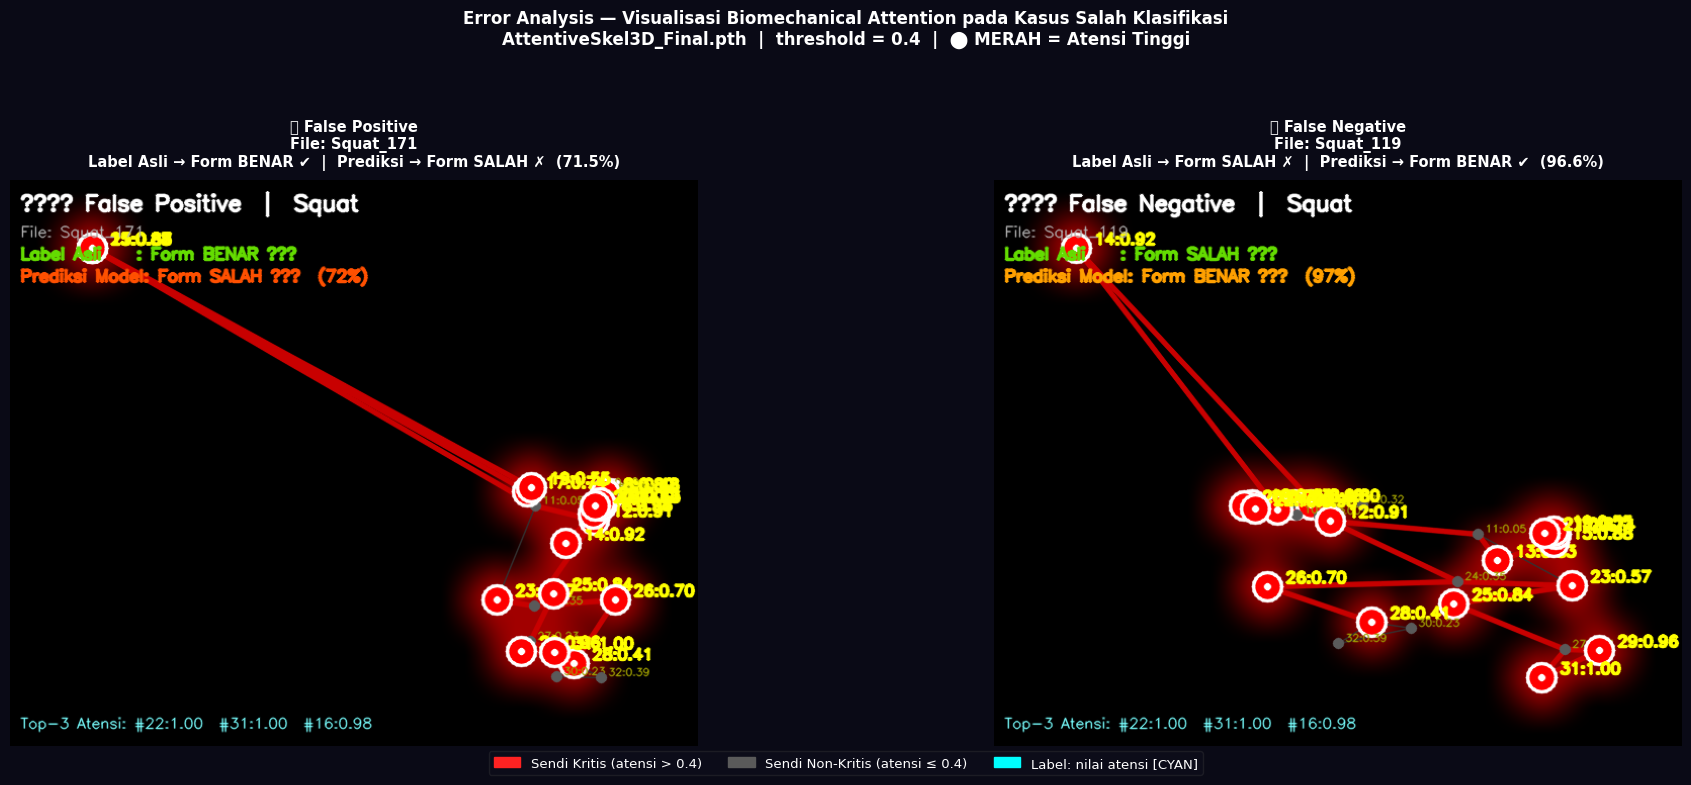


💾 Gambar tersimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\comparison_attention\error_analysis_fp_fn.jpg


In [5]:
# =============================================================================
# Render & Tampilkan Visualisasi FP dan FN Berdampingan
# =============================================================================

if false_positive is None and false_negative is None:
    print("⚠️  Tidak ada kasus FP atau FN untuk divisualisasikan.")
else:
    cases_to_visualize = []

    if false_positive is not None:
        cases_to_visualize.append({
            **false_positive,
            "error_type": "🔴 False Positive",
        })
    if false_negative is not None:
        cases_to_visualize.append({
            **false_negative,
            "error_type": "🟠 False Negative",
        })

    n_cases = len(cases_to_visualize)
    fig, axes = plt.subplots(1, n_cases, figsize=(10 * n_cases, 7.5))
    if n_cases == 1:
        axes = [axes]

    fig.patch.set_facecolor("#0a0a16")

    for ax, case in zip(axes, cases_to_visualize):

        # Render kanvas dari tensor case
        canvas_bgr = draw_skeleton_from_tensor(
            tensor_3d         = case["tensor"],
            attention_weights = attention_weights,
            case_info         = case,
            canvas_w          = 680,
            canvas_h          = 560,
            threshold         = 0.4,
        )
        canvas_rgb = cv2.cvtColor(canvas_bgr, cv2.COLOR_BGR2RGB)

        ax.imshow(canvas_rgb)

        # Judul subplot
        error_label = case["error_type"]
        label_txt   = CLASS_NAMES.get(case["label"], "")
        pred_txt    = CLASS_NAMES.get(case["pred"],  "")
        ax.set_title(
            f"{error_label}\n"
            f"File: {case['file_name']}\n"
            f"Label Asli → {label_txt}  |  Prediksi → {pred_txt}  ({case['conf']:.1f}%)",
            fontsize=10.5, fontweight="bold", color="white", pad=10,
        )
        ax.axis("off")
        ax.set_facecolor("#0a0a16")

        # Cetak Top-3 sendi ke console untuk referensi BAB 4
        top3_idx = np.argsort(attention_weights)[::-1][:3]
        print(f"\n{'─'*58}")
        print(f"  {case['error_type']}  →  {case['file_name']}")
        print(f"  Exercise : {case['exercise']}")
        print(f"  Top-3 Sendi yang Menjadi Fokus Model:")
        for rank, idx in enumerate(top3_idx, 1):
            name = JOINT_NAMES.get(int(idx), f"Landmark #{idx}")
            flag = "← KRITIS" if attention_weights[idx] > 0.4 else ""
            print(f"    {rank}. #{idx:2d}  {name:<30s}  atensi={attention_weights[idx]:.4f}  {flag}")
        print(f"\n  Reason (dari manifest):")
        print(f"  {case['reason'][:200]}")

    # Legend
    legend_patches = [
        mpatches.Patch(color="#ff2222", label="Sendi Kritis (atensi > 0.4)"),
        mpatches.Patch(color="#5a5a5a", label="Sendi Non-Kritis (atensi ≤ 0.4)"),
        mpatches.Patch(color="#00ffff", label="Label: nilai atensi [CYAN]"),
    ]
    fig.legend(
        handles=legend_patches, loc="lower center",
        ncol=3, framealpha=0.3,
        facecolor="#111120", edgecolor="#444",
        labelcolor="white", fontsize=9.5,
        bbox_to_anchor=(0.5, -0.01),
    )

    fig.suptitle(
        "Error Analysis — Visualisasi Biomechanical Attention pada Kasus Salah Klasifikasi\n"
        "AttentiveSkel3D_Final.pth  |  threshold = 0.4  |  ⬤ MERAH = Atensi Tinggi",
        fontsize=12, fontweight="bold", color="white", y=1.02,
    )
    fig.set_facecolor("#0a0a16")
    plt.tight_layout(pad=2.0)

    # Simpan gambar ke disk
    OUTPUT_DIR = ROOT_DIR / "data" / "processed" / "comparison_attention"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out_path = OUTPUT_DIR / "error_analysis_fp_fn.jpg"
    plt.savefig(str(out_path), dpi=150, bbox_inches="tight", facecolor="#0a0a16")
    plt.show()
    print(f"\n💾 Gambar tersimpan : {out_path}")

# 4. Interpretasi & Kesimpulan Error Analysis

## Cara Membaca Visualisasi

| Elemen Visual | Makna |
|---|---|
| ⬤ **Merah Terang + Glow** | Sendi dengan atensi > 0.4 — model *sangat memperhatikan* sendi ini |
| ⬤ **Abu-abu Redup** | Sendi dengan atensi ≤ 0.4 — model kurang merespons sendi ini |
| **Teks CYAN** | Nilai atensi numerik per sendi (dari BSP setelah sigmoid + normalisasi) |
| **Garis Merah Tebal** | Tulang/koneksi yang menghubungkan dua sendi kritis |
| **Garis Abu-abu Tipis** | Tulang/koneksi antar sendi non-kritis |

---

## Poin Penting untuk BAB 4 Skripsi

### Tentang False Positive (FP)

Model salah mengklasifikasikan gerakan **BENAR** sebagai **SALAH**. Kemungkinan penyebab:
- Gerakan memiliki postur yang *mirip* dengan gerakan salah pada fitur yang dipelajari model
- Atensi model mungkin terlalu sensitif pada sendi tertentu bahkan ketika nilai biomekanis masih dalam rentang normal
- Variasi individu (tinggi badan, proporsi tubuh) dapat menyebabkan koordinat landmark menyerupai postur cacat

### Tentang False Negative (FN) — Lebih Berbahaya secara Praktis

Model salah mengklasifikasikan gerakan **SALAH** sebagai **BENAR**. Kemungkinan penyebab:
- Kecacatan bentuk gerakan bersifat *subtil* dan tidak tercermin kuat pada sendi yang menjadi fokus atensi BSP
- Model mungkin kurang memperhatikan sendi-sendi yang justru krusial untuk kecacatan spesifik tersebut
- Fenomena ini disebut *under-sensitivity* dan memiliki risiko cedera yang lebih tinggi dalam konteks latihan beban nyata

### Catatan Metodologis

> Bobot atensi BSP bersifat **global** (parameter model, bukan fungsi input). Artinya, model selalu melihat sendi yang sama dengan intensitas yang sama untuk *semua* sampel. Error analysis ini memperlihatkan apakah distribusi atensi global tersebut cocok atau tidak cocok dengan kecacatan spesifik yang ada pada kasus FP dan FN.